# 📊 **APE_011: Inferencia Estadística Multigrupo: Análisis de Varianza (ANOVA de 1 factor) y Pruebas Post-Hoc (Tukey)**

---

### **GRUPO G**

#### 👥 **Integrantes:**
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera


## 📊 **Tarea 1: Análisis de Varianza (ANOVA de 1 factor)**

El ANOVA compara la varianza entre los grupos frente a la varianza dentro de los grupos.
* **H0:** Todas las medias poblacionales son iguales.
* **H1:** Al menos una media poblacional es diferente.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Ejemplo: Tiempos de respuesta (ping) de 3 algoritmos
np.random.seed(42)
grupo_A = np.random.normal(loc=45.0, scale=5.0, size=30)
grupo_B = np.random.normal(loc=46.5, scale=4.8, size=30)
grupo_C = np.random.normal(loc=52.0, scale=5.5, size=30)

stat_f, p_val_f = f_oneway(grupo_A, grupo_B, grupo_C)
print(f"Estadístico F: {stat_f:.4f} | Valor-p: {p_val_f:.4e}")

Estadístico F: 22.6087 | Valor-p: 1.2389e-08


## 🧩 **Tarea 2: Hito del Proyecto - Segmentación Multigrupo**

1. Importe su dataset regional.
2. Identifique una variable categórica con al menos 3 niveles (ej. tipo de conexión, meses, sectores).
3. Ejecute f_oneway y redacte un dictamen técnico: ¿El ANOVA sugiere que existen diferencias significativas entre los niveles? ¿Es necesario investigar más a fondo?



Distribución de los grupos
Categoria_Viviendas
Altas     6
Bajas     5
Medias    5
Name: count, dtype: int64

PRUEBA DE LEVENE
Estadístico = 1.8073
Valor-p = 0.2030
Las varianzas pueden considerarse iguales.

RESULTADOS DEL ANOVA
Estadístico F = 6.4273
Valor-p = 0.0115

Conclusión:
Se rechaza H0.
Existen diferencias significativas entre las medias de los grupos.
Se recomienda realizar una prueba Post Hoc (Tukey HSD).


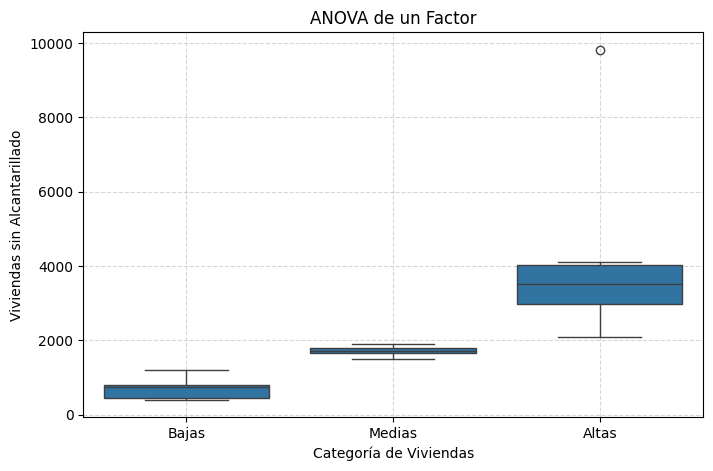

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, levene

# ==========================================
# 1. Importar el dataset
# ==========================================

df = pd.read_csv('/content/datos_loja2 (1).csv')

# ==========================================
# 2. Crear variable categórica (3 grupos)
# ==========================================

df["Categoria_Viviendas"] = pd.qcut(
    df["Viviendas"],
    q=3,
    labels=["Bajas", "Medias", "Altas"]
)

print("=========================================")
print("Distribución de los grupos")
print("=========================================")
print(df["Categoria_Viviendas"].value_counts())

# ==========================================
# 3. Crear los grupos para ANOVA
# ==========================================

grupo_bajas = df[df["Categoria_Viviendas"] == "Bajas"]["Sin_Alcantarillado"]

grupo_medias = df[df["Categoria_Viviendas"] == "Medias"]["Sin_Alcantarillado"]

grupo_altas = df[df["Categoria_Viviendas"] == "Altas"]["Sin_Alcantarillado"]

# ==========================================
# 4. Prueba de Levene
# ==========================================

estadistico_l, p_l = levene(
    grupo_bajas,
    grupo_medias,
    grupo_altas
)

print("\n=========================================")
print("PRUEBA DE LEVENE")
print("=========================================")
print(f"Estadístico = {estadistico_l:.4f}")
print(f"Valor-p = {p_l:.4f}")

if p_l > 0.05:
    print("Las varianzas pueden considerarse iguales.")
else:
    print("Las varianzas son diferentes.")

# ==========================================
# 5. ANOVA
# ==========================================

F, p = f_oneway(
    grupo_bajas,
    grupo_medias,
    grupo_altas
)

print("\n=========================================")
print("RESULTADOS DEL ANOVA")
print("=========================================")
print(f"Estadístico F = {F:.4f}")
print(f"Valor-p = {p:.4f}")

if p < 0.05:
    print("\nConclusión:")
    print("Se rechaza H0.")
    print("Existen diferencias significativas entre las medias de los grupos.")
    print("Se recomienda realizar una prueba Post Hoc (Tukey HSD).")
else:
    print("\nConclusión:")
    print("No se rechaza H0.")
    print("No existen diferencias significativas entre las medias.")

# ==========================================
# 6. Boxplot
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Categoria_Viviendas",
    y="Sin_Alcantarillado",
    data=df
)

plt.title("ANOVA de un Factor")
plt.xlabel("Categoría de Viviendas")
plt.ylabel("Viviendas sin Alcantarillado")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

## 🧪 **Tarea 3: Pruebas Post-hoc (Tukey HSD)**

Si el ANOVA rechaza H0, debemos identificar qué pares difieren.

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   1.8592 0.3003 -1.1146  4.8329  False
     A      C   8.0116    0.0  5.0378 10.9854   True
     B      C   6.1524    0.0  3.1787  9.1262   True
----------------------------------------------------


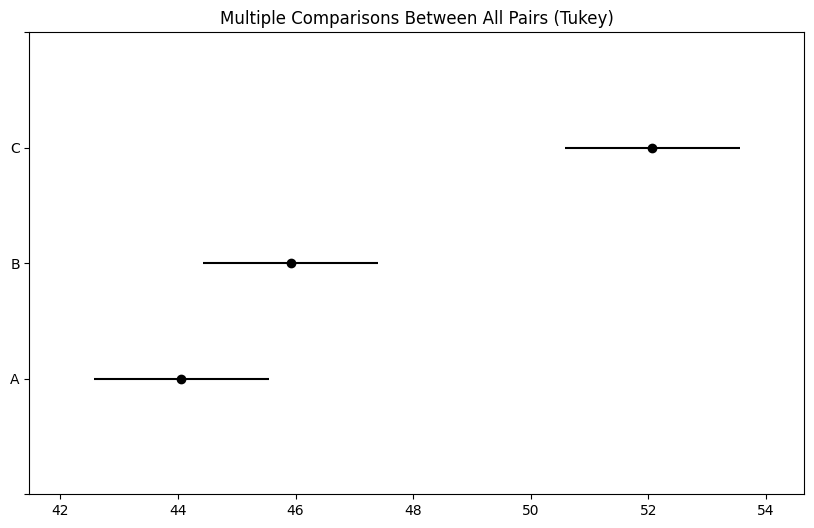

In [2]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Preparación de datos
datos_combinados = pd.DataFrame({
    'Valor': np.concatenate([grupo_A, grupo_B, grupo_C]),
    'Grupo': ['A']*30 + ['B']*30 + ['C']*30
})

# Ejecución de la prueba de Tukey HSD
tukey = pairwise_tukeyhsd(
    endog=datos_combinados['Valor'],
    groups=datos_combinados['Grupo'],
    alpha=0.05
)

print(tukey)
tukey.plot_simultaneous()
plt.show()

## 📝 **7. Preguntas de Control:**

* **Utilice scipy.stats.levene para verificar la igualdad de varianzas.**


In [12]:
from scipy.stats import levene

stat_l, p_val_l = levene(grupo_bajas, grupo_medias, grupo_altas)

print("=========================================")
print("PRUEBA DE LEVENE")
print("=========================================")
print(f"Estadístico = {stat_l:.4f}")
print(f"Valor-p = {p_val_l:.4f}")

if p_val_l > 0.05:
    print("Se cumple el supuesto de igualdad de varianzas (homocedasticidad).")
else:
    print("No se cumple el supuesto de igualdad de varianzas (heterocedasticidad).")


PRUEBA DE LEVENE
Estadístico = 1.8073
Valor-p = 0.2030
Se cumple el supuesto de igualdad de varianzas (homocedasticidad).


* **Discusión: Si el supuesto de homocedasticidad se viola, ¿qué alternativa no paramétrica (ej. Kruskal-Wallis) sería adecuada?**

    Si la prueba de Levene indica que el valor-p es menor o igual a 0.05, se concluye que no existe igualdad de varianzas entre los grupos. En este caso, el ANOVA clásico puede no ser adecuado y una alternativa no paramétrica recomendada es la prueba de Kruskal-Wallis, ya que no requiere el supuesto de homocedasticidad ni de normalidad para comparar tres o más grupos independientes.